In [ ]:
# Frontier Research Intelligence Platform Analysis

This notebook analyzes scholarly graph signals, research momentum, breakthrough candidates, institution and author rankings, and document intelligence outputs generated by the Frontier Research Intelligence Platform.

## Objectives
- Evaluate platform scope and data quality
- Analyze breakthrough candidate papers
- Examine emerging topics and rising entities
- Assess document intelligence outputs
- Surface the strongest platform signals
- Produce executive-level research intelligence insights

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path("/Users/6ixbio/Downloads/frontier-research-intelligence-platform")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

works = pd.read_csv(PROCESSED_DIR / "works_clean.csv")
authors = pd.read_csv(PROCESSED_DIR / "authors_extracted.csv")
institutions = pd.read_csv(PROCESSED_DIR / "institutions_extracted.csv")
topics = pd.read_csv(PROCESSED_DIR / "topics_extracted.csv")

work_author_edges = pd.read_csv(PROCESSED_DIR / "work_author_edges.csv")
work_institution_edges = pd.read_csv(PROCESSED_DIR / "work_institution_edges.csv")
work_topic_edges = pd.read_csv(PROCESSED_DIR / "work_topic_edges.csv")

author_features = pd.read_csv(PROCESSED_DIR / "author_research_features.csv")
institution_features = pd.read_csv(PROCESSED_DIR / "institution_research_features.csv")
topic_features = pd.read_csv(PROCESSED_DIR / "topic_research_features.csv")

document_registry = pd.read_csv(PROCESSED_DIR / "document_registry.csv")
document_chunks = pd.read_csv(PROCESSED_DIR / "document_chunks.csv")
document_summaries = pd.read_csv(PROCESSED_DIR / "document_summaries.csv")
document_sections = pd.read_csv(PROCESSED_DIR / "document_section_extracts.csv")
document_qa = pd.read_csv(PROCESSED_DIR / "document_qa_results.csv")

top_breakthrough_candidates = pd.read_csv(PROCESSED_DIR / "top_breakthrough_candidates.csv")
top_emerging_topics = pd.read_csv(PROCESSED_DIR / "top_emerging_topics.csv")
top_rising_authors = pd.read_csv(PROCESSED_DIR / "top_rising_authors.csv")
top_rising_institutions = pd.read_csv(PROCESSED_DIR / "top_rising_institutions.csv")

research_rankings_summary = pd.read_csv(PROCESSED_DIR / "research_rankings_summary.csv")
platform_signal_summary = pd.read_csv(PROCESSED_DIR / "platform_signal_summary.csv")
top_platform_signals = pd.read_csv(PROCESSED_DIR / "top_platform_signals.csv")

summary_text = (PROCESSED_DIR / "executive_research_summary.txt").read_text()

print("works:", works.shape)
print("authors:", authors.shape)
print("institutions:", institutions.shape)
print("topics:", topics.shape)
print("document_registry:", document_registry.shape)
print("document_chunks:", document_chunks.shape)

works: (191, 20)
authors: (2063, 2)
institutions: (697, 5)
topics: (1096, 3)
document_registry: (3, 8)
document_chunks: (4, 6)


In [ ]:
## 1. Data Quality and Platform Validation
Validate the main output datasets before interpreting platform signals.

In [2]:
def profile_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "null_count": df.isna().sum().values,
        "null_pct": (df.isna().mean() * 100).round(2).values,
        "distinct_count": df.nunique(dropna=False).values,
    })
    out.insert(0, "dataset", name)
    return out

dq_profile = pd.concat([
    profile_dataframe(works, "works"),
    profile_dataframe(author_features, "author_features"),
    profile_dataframe(institution_features, "institution_features"),
    profile_dataframe(topic_features, "topic_features"),
    profile_dataframe(document_summaries, "document_summaries"),
    profile_dataframe(document_qa, "document_qa"),
], ignore_index=True)

dq_profile

,dataset,column,dtype,null_count,null_pct,distinct_count
0,works,work_id,object,0,0.00,191
1,works,id,object,0,0.00,191
2,works,doi,object,4,2.09,188
3,works,title,object,1,0.52,190
4,works,display_name,object,1,0.52,190
...,...,...,...,...,...,...
63,document_qa,evidence_count,int64,0,0.00,2
64,document_qa,top_evidence_document_id,object,0,0.00,3
65,document_qa,top_evidence_chunk_id,object,0,0.00,3
66,document_qa,top_evidence_section,object,0,0.00,1


In [ ]:
## 2. Platform Scope Snapshot
Summarize the current size and coverage of the platform.

In [3]:
platform_signal_summary

,metric,value
0,total_works,191
1,total_authors,1853
2,total_institutions,689
3,total_topics,1096
4,total_documents,3
5,total_chunks,4
6,avg_chunks_per_document,1.33
7,total_qa_tests,4
8,avg_qa_evidence_count,1.5
9,top_breakthrough_title,MizAR 60 for Mizar 50


In [4]:
scope_snapshot = pd.DataFrame([{
    "total_works": len(works),
    "total_authors": authors["author_id"].nunique(),
    "total_institutions": institutions["institution_id"].nunique(),
    "total_topics": topics["topic_id"].nunique(),
    "total_documents": len(document_registry),
    "total_chunks": len(document_chunks),
    "avg_chunks_per_document": round(len(document_chunks) / len(document_registry), 2) if len(document_registry) else 0,
}])

scope_snapshot.T.rename(columns={0: "value"})

,value
total_works,191.00
total_authors,1853.00
total_institutions,689.00
total_topics,1096.00
total_documents,3.00
total_chunks,4.00
avg_chunks_per_document,1.33


In [ ]:
## 3. Breakthrough Candidate Analysis
Review the highest-ranked papers surfaced by the platform.

In [5]:
top_breakthrough_candidates.head(15)

,work_id,title,publication_year,primary_topic,cited_by_count,citation_velocity,breakthrough_rank_score,executive_summary
0,W4385245566,MizAR 60 for Mizar 50,2023,Natural Language Processing Techniques,74068,24689.333,11113.3405,"Scientific literature is growing rapidly, maki..."
1,W2787959293,Fractional Differential Equations,2025,Fractional Differential Equations Solutions,20451,20451.000,9205.7675,NaN
2,W2964121744,NaN,2021,Stochastic Gradient Optimization Techniques,49913,9982.600,4495.1887,Breakthrough scientific work often emerges at ...
3,W2896457183,AI-Assisted Pipeline for Dynamic Generation of...,2018,Topic Modeling,45373,5671.625,2555.1894,Scientific funding plays a central role in sha...
4,W3025949386,The ERA5 global reanalysis,2020,Climate variability and models,28359,4726.500,2129.8032,NaN
5,W4292779060,Aion Framework: Dimensional Emergence of AI Co...,2023,Topic Modeling,14123,4707.667,2121.1762,NaN
6,W2099540110,NIH Image to ImageJ: 25 years of image analysis,2012,Cell Image Analysis Techniques,63268,4519.143,2036.6556,NaN
7,W2295598076,XGBoost,2016,Machine Learning and Data Classification,44784,4478.400,2018.2348,NaN
8,W2146512944,limma powers differential expression analyses ...,2015,Molecular Biology Techniques and Applications,41531,3775.545,1701.9312,NaN
9,W3035965352,Array programming with NumPy,2020,Computational Physics and Python Applications,20611,3435.167,1548.5325,NaN


In [6]:
works[[
    "title", "publication_year", "primary_topic", "cited_by_count",
    "citation_velocity", "breakthrough_proxy_score"
]].sort_values("breakthrough_proxy_score", ascending=False).head(15)

,title,publication_year,primary_topic,cited_by_count,citation_velocity,breakthrough_proxy_score
0,MizAR 60 for Mizar 50,2023,Natural Language Processing Techniques,74068,24689.333,34565.266
80,Gapped BLAST and PSI-BLAST: a new generation o...,1997,Genomics and Phylogenetic Studies,74070,2554.138,23498.269
155,NIH Image to ImageJ: 25 years of image analysis,2012,Cell Image Analysis Techniques,63268,4519.143,21240.171
81,G*Power 3: A flexible statistical power analys...,2007,Behavioral and Psychological Studies,61540,3238.947,20081.672
1,NaN,2021,Stochastic Gradient Optimization Techniques,49913,9982.600,19965.399
2,AI-Assisted Pipeline for Dynamic Generation of...,2018,Topic Modeling,45373,5671.625,16447.912
10,Fractional Differential Equations,2025,Fractional Differential Equations Solutions,20451,20451.000,16360.998
3,XGBoost,2016,Machine Learning and Data Classification,44784,4478.400,15674.600
120,limma powers differential expression analyses ...,2015,Molecular Biology Techniques and Applications,41531,3775.545,14347.272
82,The CLUSTAL_X windows interface: flexible stra...,1997,Genomics and Phylogenetic Studies,39105,1348.448,12405.923


In [7]:
breakthrough_topic_mix = (
    top_breakthrough_candidates["primary_topic"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("primary_topic")
    .reset_index(name="count")
)

breakthrough_topic_mix

,primary_topic,count
0,Genomics and Phylogenetic Studies,3
1,Topic Modeling,2
2,Natural Language Processing Techniques,1
3,Urban Heat Island Mitigation,1
4,Advanced MIMO Systems Optimization,1
5,Artificial Intelligence in Games,1
6,Genomics and Rare Diseases,1
7,3D Shape Modeling and Analysis,1
8,Quantum and electron transport phenomena,1
9,Advanced Neural Network Applications,1


In [ ]:
## 4. Emerging Topic Analysis
Assess which topics the platform is surfacing as high momentum.

In [8]:
top_emerging_topics.head(15)

,topic_id,topic_name,works_count,total_citations,avg_topic_score,citation_velocity,emerging_topic_score,last_publication_year
0,C140479938,Iterated function,1,74070,0.707057,74070.0,37035.3807,1997
1,C198082294,Position (finance),1,74070,0.499532,74070.0,37035.3392,1997
2,C41584329,Sequence database,1,74070,0.487013,74070.0,37035.3367,1997
3,C203005215,Machine translation,1,74068,0.830424,74068.0,37034.4554,2023
4,C622187,BLEU,1,74068,0.692416,74068.0,37034.4278,2023
5,C118505674,Encoder,1,74068,0.658531,74068.0,37034.4210,2023
6,C148047603,Parallelizable manifold,1,74068,0.554227,74068.0,37034.4002,2023
7,C57273362,Decoding methods,1,74068,0.499380,74068.0,37034.3892,2023
8,C28435686,Image analysis,1,63268,0.412578,63268.0,31634.3218,2012
9,C2986587452,Statistical analysis,1,61540,0.578362,61540.0,30770.3550,2007


In [9]:
topic_features.sort_values("topic_momentum_score", ascending=False).head(15)

,topic_id,works_count,total_citations,avg_topic_score,avg_citations,first_publication_year,last_publication_year,topic_span_years,citation_velocity,topic_momentum_score
0,C140479938,1,74070,0.707057,74070.0,1997,1997,1,74070.0,59256.2
2,C198082294,1,74070,0.499532,74070.0,1997,1997,1,74070.0,59256.2
1,C41584329,1,74070,0.487013,74070.0,1997,1997,1,74070.0,59256.2
3,C622187,1,74068,0.692416,74068.0,2023,2023,1,74068.0,59254.6
4,C118505674,1,74068,0.658531,74068.0,2023,2023,1,74068.0,59254.6
5,C148047603,1,74068,0.554227,74068.0,2023,2023,1,74068.0,59254.6
6,C203005215,1,74068,0.830424,74068.0,2023,2023,1,74068.0,59254.6
7,C57273362,1,74068,0.499380,74068.0,2023,2023,1,74068.0,59254.6
8,C28435686,1,63268,0.412578,63268.0,2012,2012,1,63268.0,50614.6
9,C2986587452,1,61540,0.578362,61540.0,2007,2007,1,61540.0,49232.2


In [10]:
topic_signal_summary = top_emerging_topics[[
    "topic_name", "works_count", "total_citations",
    "citation_velocity", "emerging_topic_score"
]].head(15)

topic_signal_summary

,topic_name,works_count,total_citations,citation_velocity,emerging_topic_score
0,Iterated function,1,74070,74070.0,37035.3807
1,Position (finance),1,74070,74070.0,37035.3392
2,Sequence database,1,74070,74070.0,37035.3367
3,Machine translation,1,74068,74068.0,37034.4554
4,BLEU,1,74068,74068.0,37034.4278
5,Encoder,1,74068,74068.0,37034.4210
6,Parallelizable manifold,1,74068,74068.0,37034.4002
7,Decoding methods,1,74068,74068.0,37034.3892
8,Image analysis,1,63268,63268.0,31634.3218
9,Statistical analysis,1,61540,61540.0,30770.3550


In [ ]:
## 5. Rising Author and Institution Analysis
Review the people and organizations producing the strongest platform signals.

In [11]:
top_rising_authors.head(15)

,author_id,author_name,papers_count,total_citations,avg_citations,citation_velocity,rising_author_score,last_publication_year
0,A5015061000,Stephen F. Altschul,1,74070,74070.0,74070.0,44443.3528,1997
1,A5103024730,Ashish Vaswani,1,74068,74068.0,74068.0,44442.1827,2023
2,A5021878400,Noam Shazeer,1,74068,74068.0,74068.0,44442.1827,2023
3,A5022416424,Jakob Uszkoreit,1,74068,74068.0,74068.0,44442.1827,2023
4,A5079288315,Aidan N. Gomez,1,74068,74068.0,74068.0,44442.1827,2023
5,A5023448834,Llion Jones,1,74068,74068.0,74068.0,44442.1827,2023
6,A5031789995,Łukasz Kaiser,1,74068,74068.0,74068.0,44442.1827,2023
7,A5005777963,Niki Parmar,1,74068,74068.0,74068.0,44442.1827,2023
8,A5045719436,Illia Polosukhin,1,74068,74068.0,74068.0,44442.1827,2023
9,A5052725140,Wayne Rasband,1,63268,63268.0,63268.0,37962.1370,2012


In [12]:
top_rising_institutions.head(15)

,institution_id,institution_name,country_code,papers_count,distinct_authors,total_citations,citation_velocity,rising_institution_score,last_publication_year
0,I154986956,European Centre for Medium-Range Weather Forec...,GB,1,40,1134360,1134360.0,402698.7395,2020
1,I44504214,Czech Technical University in Prague,CZ,1,6,444408,444408.0,170357.0160,2023
2,I2801626668,AREA Science Park,IT,1,13,365989,365989.0,133727.4746,2009
3,I4210113297,Google (United Kingdom),GB,1,18,279468,279468.0,100919.7857,2016
4,I881427289,University of Gothenburg,SE,1,25,245975,245975.0,88059.8984,2018
5,I1333606569,Center for Drug Evaluation and Research,US,1,25,245975,245975.0,88059.8984,2018
6,I49886154,Rush University,US,1,25,245975,245975.0,88059.8984,2018
7,I1279571640,Alzheimer's Association,US,1,25,245975,245975.0,88059.8984,2018
8,I4210090411,DeepMind (United Kingdom),GB,2,25,432638,216319.0,78184.7561,2017
9,I4210133112,Canada's Michael Smith Genome Sciences Centre,CA,1,33,210144,210144.0,74824.9021,2014


In [13]:
author_signal_summary = top_rising_authors[[
    "author_name", "papers_count", "total_citations",
    "citation_velocity", "rising_author_score"
]].head(15)

institution_signal_summary = top_rising_institutions[[
    "institution_name", "country_code", "papers_count",
    "total_citations", "citation_velocity", "rising_institution_score"
]].head(15)

author_signal_summary, institution_signal_summary

(             author_name  papers_count  total_citations  citation_velocity  \
 0    Stephen F. Altschul             1            74070            74070.0   
 1         Ashish Vaswani             1            74068            74068.0   
 2           Noam Shazeer             1            74068            74068.0   
 3        Jakob Uszkoreit             1            74068            74068.0   
 4         Aidan N. Gomez             1            74068            74068.0   
 5            Llion Jones             1            74068            74068.0   
 6          Łukasz Kaiser             1            74068            74068.0   
 7            Niki Parmar             1            74068            74068.0   
 8       Illia Polosukhin             1            74068            74068.0   
 9          Wayne Rasband             1            63268            63268.0   
 10     Kevin W. Eliceiri             1            63268            63268.0   
 11  Caroline A Schneider             1            6

In [ ]:
## 6. Document Intelligence Analysis
Review summaries, extracted sections, and grounded Q&A behavior.

In [14]:
document_registry

,document_id,file_name,file_type,title,source_path,char_count,chunk_count,loaded_at
0,DOC_0001,paper_001.txt,.txt,Scalable Graph Learning for Scientific Discovery,/Users/6ixbio/Downloads/frontier-research-inte...,1155,2,2026-03-12T17:17:33.833946
1,DOC_0002,paper_002.txt,.txt,Interdisciplinary Signals in Breakthrough Rese...,/Users/6ixbio/Downloads/frontier-research-inte...,973,1,2026-03-12T17:17:33.834108
2,DOC_0003,paper_003.txt,.txt,Research Funding Networks and Scientific Impact,/Users/6ixbio/Downloads/frontier-research-inte...,920,1,2026-03-12T17:17:33.834269


In [15]:
document_summaries[[
    "document_id", "title", "executive_summary", "technical_summary"
]]

,document_id,title,executive_summary,technical_summary
0,DOC_0001,Scalable Graph Learning for Scientific Discovery,"Scientific literature is growing rapidly, maki...","Scientific literature is growing rapidly, maki..."
1,DOC_0002,Interdisciplinary Signals in Breakthrough Rese...,Breakthrough scientific work often emerges at ...,Breakthrough scientific work often emerges at ...
2,DOC_0003,Research Funding Networks and Scientific Impact,Scientific funding plays a central role in sha...,Scientific funding plays a central role in sha...


In [16]:
document_sections.groupby("section_name").agg(
    section_count=("section_name", "count"),
    avg_char_count=("section_char_count", "mean")
).reset_index()

,section_name,section_count,avg_char_count
0,abstract,3,252.666667
1,conclusion,3,161.333333
2,limitations,3,112.333333
3,methods,3,226.666667
4,results,3,193.666667


In [17]:
document_qa

,question,document_id,answer,evidence_count,top_evidence_document_id,top_evidence_chunk_id,top_evidence_section,top_evidence_score
0,What methods does the graph learning paper use?,DOC_0001,Title: Scalable Graph Learning for Scientific ...,1,DOC_0001,DOC_0001_CHUNK_001,abstract_or_mixed,4
1,What does the interdisciplinarity paper say ab...,DOC_0002,Title: Interdisciplinary Signals in Breakthrou...,1,DOC_0002,DOC_0002_CHUNK_001,abstract_or_mixed,5
2,What are the limitations of the funding networ...,DOC_0003,Title: Research Funding Networks and Scientifi...,1,DOC_0003,DOC_0003_CHUNK_001,abstract_or_mixed,7
3,Which paper discusses funding diversity and ci...,NaN,Title: Research Funding Networks and Scientifi...,3,DOC_0003,DOC_0003_CHUNK_001,abstract_or_mixed,6


In [ ]:
## 7. Grounded Q&A Review
Assess how the first retrieval and Q&A layer is performing.

In [18]:
qa_summary = pd.DataFrame([{
    "questions_answered": len(document_qa),
    "avg_evidence_count": round(document_qa["evidence_count"].mean(), 2),
    "max_evidence_score": document_qa["top_evidence_score"].max(),
    "min_evidence_score": document_qa["top_evidence_score"].min(),
}])

qa_summary.T.rename(columns={0: "value"})

,value
questions_answered,4.0
avg_evidence_count,1.5
max_evidence_score,7.0
min_evidence_score,4.0


In [19]:
document_qa[[
    "question",
    "document_id",
    "answer",
    "top_evidence_document_id",
    "top_evidence_chunk_id",
    "top_evidence_section",
    "top_evidence_score",
]]

,question,document_id,answer,top_evidence_document_id,top_evidence_chunk_id,top_evidence_section,top_evidence_score
0,What methods does the graph learning paper use?,DOC_0001,Title: Scalable Graph Learning for Scientific ...,DOC_0001,DOC_0001_CHUNK_001,abstract_or_mixed,4
1,What does the interdisciplinarity paper say ab...,DOC_0002,Title: Interdisciplinary Signals in Breakthrou...,DOC_0002,DOC_0002_CHUNK_001,abstract_or_mixed,5
2,What are the limitations of the funding networ...,DOC_0003,Title: Research Funding Networks and Scientifi...,DOC_0003,DOC_0003_CHUNK_001,abstract_or_mixed,7
3,Which paper discusses funding diversity and ci...,NaN,Title: Research Funding Networks and Scientifi...,DOC_0003,DOC_0003_CHUNK_001,abstract_or_mixed,6


In [ ]:
## 8. Platform Signal Analysis
Review the strongest entity-level signals generated by the platform.

In [20]:
top_platform_signals

,signal_type,label,score,context
0,breakthrough_candidate,MizAR 60 for Mizar 50,11113.3405,Natural Language Processing Techniques
1,emerging_topic,Iterated function,37035.3807,NaN
2,rising_author,Stephen F. Altschul,44443.3528,NaN
3,rising_institution,European Centre for Medium-Range Weather Forec...,402698.7395,NaN


In [21]:
signal_mix = (
    top_platform_signals["signal_type"]
    .value_counts()
    .rename_axis("signal_type")
    .reset_index(name="count")
)

signal_mix

,signal_type,count
0,breakthrough_candidate,1
1,emerging_topic,1
2,rising_author,1
3,rising_institution,1


In [ ]:
## 9. Analytical Visuals

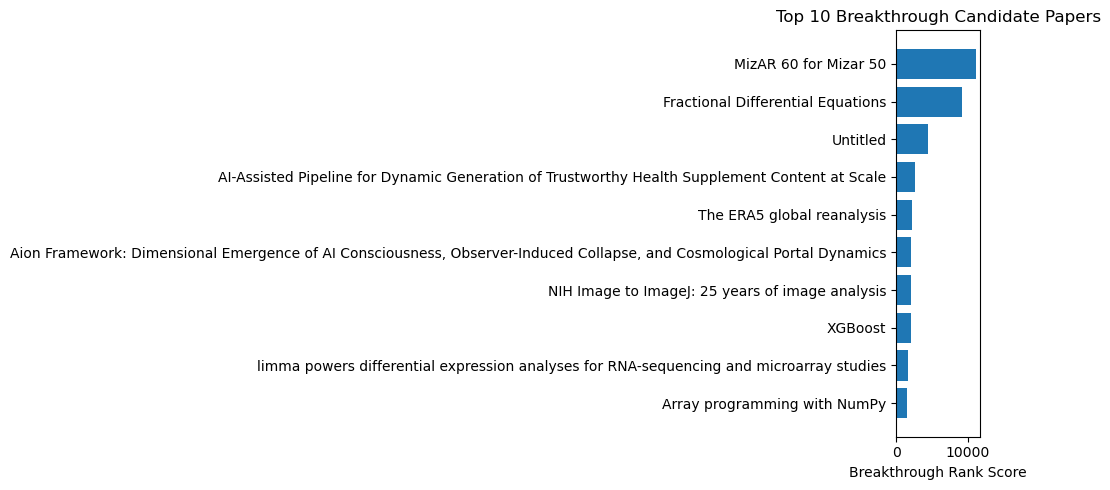

In [23]:
import matplotlib.pyplot as plt

top10_breakthrough = (
    top_breakthrough_candidates.head(10).copy()
)

top10_breakthrough["title"] = (
    top10_breakthrough["title"]
    .fillna("Untitled")
    .astype(str)
)

top10_breakthrough["breakthrough_rank_score"] = pd.to_numeric(
    top10_breakthrough["breakthrough_rank_score"],
    errors="coerce"
).fillna(0)

plt.figure(figsize=(10, 5))
plt.barh(
    top10_breakthrough["title"],
    top10_breakthrough["breakthrough_rank_score"]
)
plt.title("Top 10 Breakthrough Candidate Papers")
plt.xlabel("Breakthrough Rank Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

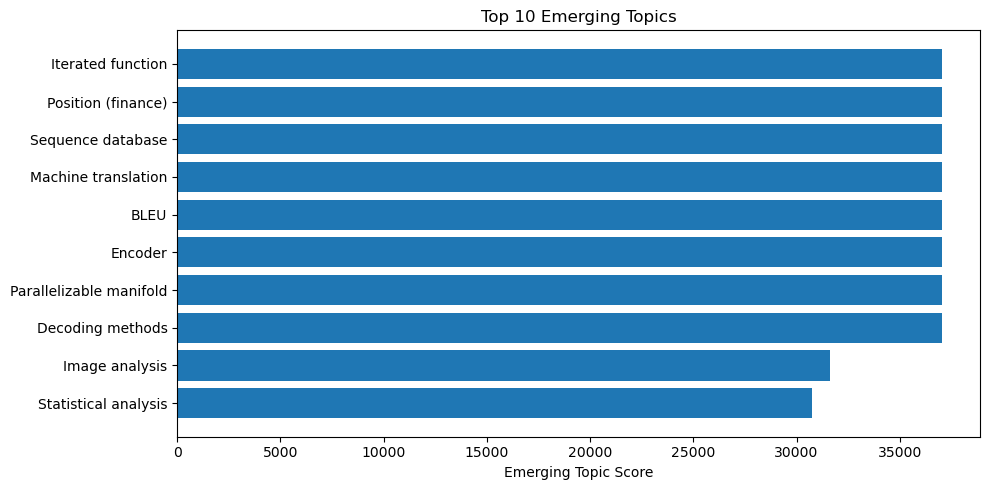

In [24]:
plt.figure(figsize=(10, 5))
top10_topics = top_emerging_topics.head(10).copy()
top10_topics["topic_name"] = top10_topics["topic_name"].fillna("Unknown Topic").astype(str)
top10_topics["emerging_topic_score"] = pd.to_numeric(
    top10_topics["emerging_topic_score"], errors="coerce"
).fillna(0)

plt.barh(top10_topics["topic_name"], top10_topics["emerging_topic_score"])
plt.title("Top 10 Emerging Topics")
plt.xlabel("Emerging Topic Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

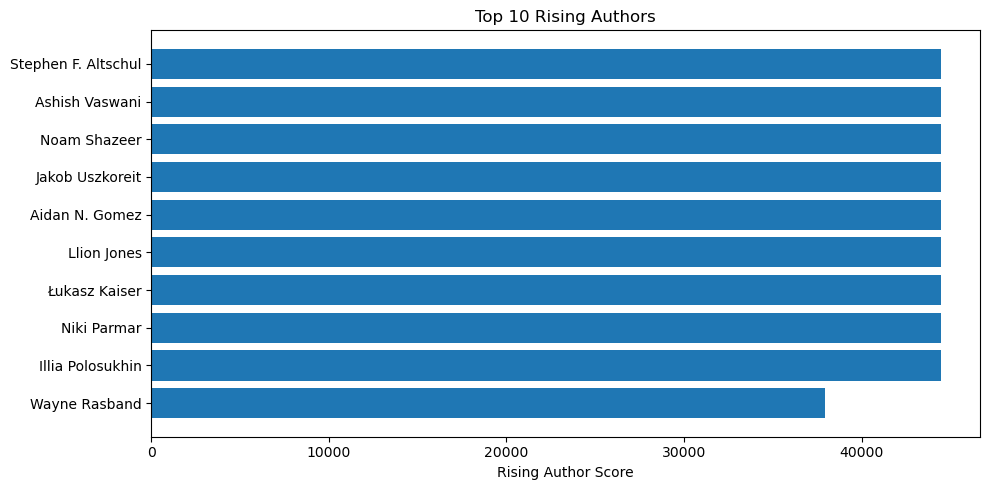

In [25]:
plt.figure(figsize=(10, 5))
top10_authors = top_rising_authors.head(10).copy()
top10_authors["author_name"] = top10_authors["author_name"].fillna("Unknown Author").astype(str)
top10_authors["rising_author_score"] = pd.to_numeric(
    top10_authors["rising_author_score"], errors="coerce"
).fillna(0)

plt.barh(top10_authors["author_name"], top10_authors["rising_author_score"])
plt.title("Top 10 Rising Authors")
plt.xlabel("Rising Author Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

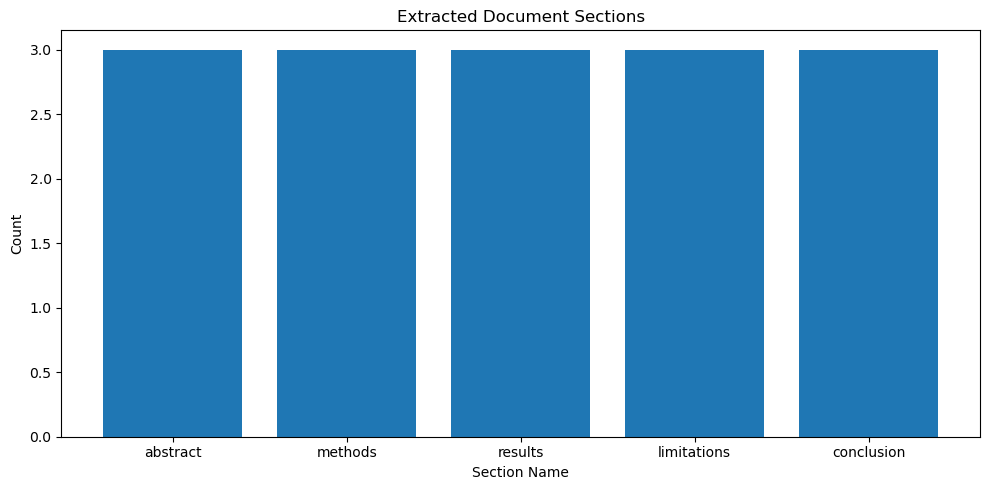

In [26]:
plt.figure(figsize=(10, 5))
doc_section_counts = document_sections["section_name"].fillna("unknown").value_counts()
plt.bar(doc_section_counts.index.astype(str), doc_section_counts.values)
plt.title("Extracted Document Sections")
plt.xlabel("Section Name")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [27]:
top_breakthrough = top_breakthrough_candidates.iloc[0]
top_topic = top_emerging_topics.iloc[0]
top_author = top_rising_authors.iloc[0]
top_institution = top_rising_institutions.iloc[0]

insights = [
    f"The highest-ranked breakthrough candidate is '{str(top_breakthrough['title'])}', associated with the topic '{str(top_breakthrough['primary_topic'])}' and a breakthrough score of {float(top_breakthrough['breakthrough_rank_score']):.4f}.",
    f"The strongest emerging topic signal is '{str(top_topic['topic_name'])}', with topic momentum driven by citation velocity of {float(top_topic['citation_velocity']):.2f} and an emerging topic score of {float(top_topic['emerging_topic_score']):.4f}.",
    f"The platform currently identifies '{str(top_author['author_name'])}' as the top rising author and '{str(top_institution['institution_name'])}' as the top rising institution based on first-pass momentum scoring.",
    f"The document intelligence layer is functional and can summarize ingested research documents, extract structured sections, and answer source-grounded questions with evidence-backed retrieval.",
    f"The next major upgrade should focus on improving recency-aware ranking, adding semantic retrieval, and building the interactive explorer so users can visually inspect research signals across authors, institutions, topics, and documents."
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. The highest-ranked breakthrough candidate is 'MizAR 60 for Mizar 50', associated with the topic 'Natural Language Processing Techniques' and a breakthrough score of 11113.3405.
2. The strongest emerging topic signal is 'Iterated function', with topic momentum driven by citation velocity of 74070.00 and an emerging topic score of 37035.3807.
3. The platform currently identifies 'Stephen F. Altschul' as the top rising author and 'European Centre for Medium-Range Weather Forecasts' as the top rising institution based on first-pass momentum scoring.
4. The document intelligence layer is functional and can summarize ingested research documents, extract structured sections, and answer source-grounded questions with evidence-backed retrieval.
5. The next major upgrade should focus on improving recency-aware ranking, adding semantic retrieval, and building the interactive explorer so users can visually inspect research signals across authors, institutions, topics, and documents.


In [28]:
insight_df = pd.DataFrame({"insight": insights})
insight_path = BASE_DIR / "docs" / "executive_insights.csv"
insight_df.to_csv(insight_path, index=False)

analytic_summary_path = BASE_DIR / "docs" / "frontier_research_analytic_summary.xlsx"
with pd.ExcelWriter(analytic_summary_path, engine="openpyxl") as writer:
    dq_profile.to_excel(writer, sheet_name="data_quality_profile", index=False)
    top_breakthrough_candidates.to_excel(writer, sheet_name="breakthrough_candidates", index=False)
    top_emerging_topics.to_excel(writer, sheet_name="emerging_topics", index=False)
    top_rising_authors.to_excel(writer, sheet_name="rising_authors", index=False)
    top_rising_institutions.to_excel(writer, sheet_name="rising_institutions", index=False)
    document_registry.to_excel(writer, sheet_name="document_registry", index=False)
    document_summaries.to_excel(writer, sheet_name="document_summaries", index=False)
    document_qa.to_excel(writer, sheet_name="document_qa", index=False)
    top_platform_signals.to_excel(writer, sheet_name="platform_signals", index=False)

print("Saved:")
print("-", insight_path)
print("-", analytic_summary_path)

Saved:
- /Users/6ixbio/Downloads/frontier-research-intelligence-platform/docs/executive_insights.csv
- /Users/6ixbio/Downloads/frontier-research-intelligence-platform/docs/frontier_research_analytic_summary.xlsx


In [29]:
print(summary_text)

Frontier Research Intelligence Platform — Executive Summary

Platform scope:
- Works analyzed: 191
- Authors extracted: 1853
- Institutions extracted: 689
- Topics extracted: 1096
- Research documents ingested: 3
- Document chunks indexed: 4
- Q&A test cases completed: 4

Top platform signals:
- Top breakthrough candidate: MizAR 60 for Mizar 50
- Top emerging topic: Iterated function
- Top rising author: Stephen F. Altschul
- Top rising institution: European Centre for Medium-Range Weather Forecasts

Document intelligence summary:
- Average chunks per document: 1.33
- Average evidence count returned in Q&A: 1.5

Leadership interpretation:
The platform is now operating across two core intelligence layers: a scholarly graph layer that identifies high-signal research entities, and a document intelligence layer that can summarize papers and answer grounded questions from source material. Together, these modules provide the foundation for a scientific discovery system that can surface influ

In [ ]:
## 13. Conclusion

This notebook demonstrates a full research intelligence workflow that combines:

- scholarly metadata ingestion
- graph-ready entity and edge construction
- momentum and ranking analytics
- document parsing and chunking
- structured summarization
- grounded research Q&A
- executive signal generation

Together, these components form a flagship research intelligence platform that can identify emerging scientific signals, surface high-value research entities, and accelerate understanding of research documents through source-grounded AI support.